# การจัดการข้อมูลหลายมิติด้วย NumPy
## วิชา GE 234 Basic Programming for Geographers
### สัปดาห์ที่ 9 (2 มีนาคม 2569)

---

**วัตถุประสงค์การเรียนรู้:**
1. เข้าใจแนวคิดของ NumPy Array และข้อดีเมื่อเทียบกับ Python List
2. สามารถสร้างและจัดการอาร์เรย์ 1 มิติ, 2 มิติ และ 3 มิติ ได้
3. ใช้การ Indexing, Slicing และ Reshaping ข้อมูลได้
4. ประยุกต์ใช้ NumPy กับข้อมูลทางภูมิศาสตร์ เช่น DEM, อุณหภูมิ, NDVI

---
# ส่วนที่ 1: ทำไมต้อง NumPy?

NumPy (Numerical Python) เป็นไลบรารีหลักสำหรับการคำนวณเชิงตัวเลขใน Python

**ข้อดีของ NumPy เมื่อเทียบกับ Python List:**
- คำนวณเร็วกว่ามาก (เขียนด้วย C/Fortran)
- ใช้หน่วยความจำน้อยกว่า
- มีฟังก์ชันทางคณิตศาสตร์และสถิติพร้อมใช้งาน
- รองรับข้อมูลหลายมิติ (เหมาะกับข้อมูล Raster, DEM, ภาพถ่ายดาวเทียม)

In [1]:
# ติดตั้ง NumPy (ถ้ายังไม่มี)
# !pip install numpy

import numpy as np
print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


### เปรียบเทียบความเร็ว: Python List vs NumPy Array

In [2]:
import time

# สร้างข้อมูลขนาดใหญ่
size = 1_000_000

# === Python List ===
py_list = list(range(size))
start = time.time()
result_list = [x * 2 for x in py_list]
time_list = time.time() - start

# === NumPy Array ===
np_array = np.arange(size)
start = time.time()
result_np = np_array * 2
time_np = time.time() - start

print(f"Python List: {time_list:.4f} วินาที")
print(f"NumPy Array: {time_np:.4f} วินาที")
print(f"NumPy เร็วกว่า {time_list/time_np:.1f} เท่า!")

Python List: 0.2430 วินาที
NumPy Array: 0.0170 วินาที
NumPy เร็วกว่า 14.3 เท่า!


---
# ส่วนที่ 2: การสร้าง NumPy Array

## 2.1 สร้าง Array จาก List

In [3]:
# อาร์เรย์ 1 มิติ (1D Array) - เหมือนข้อมูลแถวเดียว
temp_daily = np.array([28.5, 30.2, 29.8, 31.0, 27.5])
print("อุณหภูมิรายวัน:", temp_daily)
print("ชนิดข้อมูล:", temp_daily.dtype)
print("จำนวนมิติ:", temp_daily.ndim)
print("รูปร่าง (shape):", temp_daily.shape)
print("จำนวนสมาชิก:", temp_daily.size)

อุณหภูมิรายวัน: [28.5 30.2 29.8 31.  27.5]
ชนิดข้อมูล: float64
จำนวนมิติ: 1
รูปร่าง (shape): (5,)
จำนวนสมาชิก: 5


In [4]:
# อาร์เรย์ 2 มิติ (2D Array) - เหมือนตาราง (แถว x คอลัมน์)
# ตัวอย่าง: อุณหภูมิ 3 จังหวัด x 4 วัน
temp_grid = np.array([
    [28.5, 30.2, 29.8, 31.0],   # กรุงเทพฯ
    [25.0, 26.5, 24.8, 27.2],   # เชียงใหม่
    [30.5, 31.8, 32.0, 30.5]    # สงขลา
])
print("ตารางอุณหภูมิ:")
print(temp_grid)
print(f"รูปร่าง: {temp_grid.shape} (3 จังหวัด x 4 วัน)")
print(f"จำนวนมิติ: {temp_grid.ndim}")

ตารางอุณหภูมิ:
[[28.5 30.2 29.8 31. ]
 [25.  26.5 24.8 27.2]
 [30.5 31.8 32.  30.5]]
รูปร่าง: (3, 4) (3 จังหวัด x 4 วัน)
จำนวนมิติ: 2


In [5]:
# อาร์เรย์ 3 มิติ (3D Array) - เหมือนข้อมูล Raster หลายแบนด์
# ตัวอย่าง: ภาพถ่ายดาวเทียม 3 แบนด์ x 4 แถว x 5 คอลัมน์
satellite = np.array([
    # Band 1 (Red)
    [[120, 130, 125, 140, 135],
     [110, 115, 120, 130, 125],
     [100, 105, 110, 115, 120],
     [95,  100, 105, 110, 115]],
    # Band 2 (Green)
    [[80, 85, 90, 95, 88],
     [75, 78, 82, 88, 85],
     [70, 72, 75, 80, 78],
     [65, 68, 70, 75, 72]],
    # Band 3 (NIR)
    [[200, 210, 205, 220, 215],
     [190, 195, 200, 210, 205],
     [180, 185, 190, 195, 200],
     [175, 180, 185, 190, 195]]
])
print(f"ภาพถ่ายดาวเทียม shape: {satellite.shape}")
print(f"จำนวนมิติ: {satellite.ndim}")
print(f"ความหมาย: {satellite.shape[0]} แบนด์ x {satellite.shape[1]} แถว x {satellite.shape[2]} คอลัมน์")

ภาพถ่ายดาวเทียม shape: (3, 4, 5)
จำนวนมิติ: 3
ความหมาย: 3 แบนด์ x 4 แถว x 5 คอลัมน์


## 2.2 สร้าง Array แบบพิเศษ

In [6]:
# อาร์เรย์ที่เป็นศูนย์ทั้งหมด
zeros = np.zeros((3, 4))
print("Zeros (3x4):")
print(zeros)
print()

# อาร์เรย์ที่เป็นหนึ่งทั้งหมด
ones = np.ones((2, 5))
print("Ones (2x5):")
print(ones)
print()

# อาร์เรย์เต็มด้วยค่าที่กำหนด
nodata = np.full((3, 3), -9999)
print("NoData grid (3x3):")
print(nodata)

Zeros (3x4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Ones (2x5):
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

NoData grid (3x3):
[[-9999 -9999 -9999]
 [-9999 -9999 -9999]
 [-9999 -9999 -9999]]


In [7]:
# arange - สร้างลำดับตัวเลข (คล้าย range)
elevations = np.arange(0, 1000, 100)
print("ระดับความสูง:", elevations)

# linspace - สร้างตัวเลขเว้นระยะเท่ากัน
latitudes = np.linspace(5.0, 20.0, 5)
print("ละติจูด:", latitudes)

# สร้างข้อมูลสุ่ม
rainfall = np.random.uniform(0, 100, size=(3, 4))
print("\nปริมาณฝนสุ่ม (3 สถานี x 4 วัน):")
print(rainfall.round(1))

ระดับความสูง: [  0 100 200 300 400 500 600 700 800 900]
ละติจูด: [ 5.    8.75 12.5  16.25 20.  ]

ปริมาณฝนสุ่ม (3 สถานี x 4 วัน):
[[ 9.1 82.5 23.4 42. ]
 [15.8 13.5 75.8 69.6]
 [94.6 76.6 35.6  1.2]]


---
# ส่วนที่ 3: การเข้าถึงข้อมูล (Indexing & Slicing)

## 3.1 Indexing - เข้าถึงค่าเฉพาะจุด

In [8]:
# === 1D Array ===
temp = np.array([28.5, 30.2, 29.8, 31.0, 27.5])

print("ค่าแรก:", temp[0])        # index 0
print("ค่าสุดท้าย:", temp[-1])   # index -1
print("ค่าที่ 3:", temp[2])      # index 2

ค่าแรก: 28.5
ค่าสุดท้าย: 27.5
ค่าที่ 3: 29.8


In [9]:
# === 2D Array ===
# อุณหภูมิ: [จังหวัด, วัน]
temp_grid = np.array([
    [28.5, 30.2, 29.8, 31.0],   # แถว 0: กรุงเทพฯ
    [25.0, 26.5, 24.8, 27.2],   # แถว 1: เชียงใหม่
    [30.5, 31.8, 32.0, 30.5]    # แถว 2: สงขลา
])
provinces = ["กรุงเทพฯ", "เชียงใหม่", "สงขลา"]

# เข้าถึงค่าเฉพาะ [แถว, คอลัมน์]
print(f"อุณหภูมิ {provinces[0]} วันที่ 1: {temp_grid[0, 0]} °C")
print(f"อุณหภูมิ {provinces[1]} วันที่ 3: {temp_grid[1, 2]} °C")
print(f"อุณหภูมิ {provinces[2]} วันที่ 4: {temp_grid[2, 3]} °C")

อุณหภูมิ กรุงเทพฯ วันที่ 1: 28.5 °C
อุณหภูมิ เชียงใหม่ วันที่ 3: 24.8 °C
อุณหภูมิ สงขลา วันที่ 4: 30.5 °C


## 3.2 Slicing - เลือกช่วงข้อมูล

In [10]:
# === 1D Slicing ===
pm25 = np.array([45, 78, 120, 55, 90, 35, 150, 65])
days = ["จ.", "อ.", "พ.", "พฤ.", "ศ.", "ส.", "อา.", "จ."]

print("PM2.5 ทั้งสัปดาห์:", pm25)
print("3 วันแรก:", pm25[:3])         # index 0, 1, 2
print("3 วันสุดท้าย:", pm25[-3:])    # index -3, -2, -1
print("วันที่ 2-5:", pm25[1:5])      # index 1, 2, 3, 4
print("เว้นวัน:", pm25[::2])         # ทุก 2 ตัว

PM2.5 ทั้งสัปดาห์: [ 45  78 120  55  90  35 150  65]
3 วันแรก: [ 45  78 120]
3 วันสุดท้าย: [ 35 150  65]
วันที่ 2-5: [ 78 120  55  90]
เว้นวัน: [ 45 120  90 150]


In [11]:
# === 2D Slicing ===
temp_grid = np.array([
    [28.5, 30.2, 29.8, 31.0],   # กรุงเทพฯ
    [25.0, 26.5, 24.8, 27.2],   # เชียงใหม่
    [30.5, 31.8, 32.0, 30.5]    # สงขลา
])

# เลือกทั้งแถว (จังหวัดเดียว)
print("เชียงใหม่ ทุกวัน:", temp_grid[1, :])    # หรือ temp_grid[1]

# เลือกทั้งคอลัมน์ (วันเดียว)
print("ทุกจังหวัด วันที่ 1:", temp_grid[:, 0])

# เลือก sub-grid
print("\n2 จังหวัดแรก x 3 วันแรก:")
print(temp_grid[:2, :3])

เชียงใหม่ ทุกวัน: [25.  26.5 24.8 27.2]
ทุกจังหวัด วันที่ 1: [28.5 25.  30.5]

2 จังหวัดแรก x 3 วันแรก:
[[28.5 30.2 29.8]
 [25.  26.5 24.8]]


## 3.3 Boolean Indexing - เลือกข้อมูลตามเงื่อนไข

In [12]:
pm25 = np.array([45, 78, 120, 55, 90, 35, 150, 65])
days = np.array(["จ.", "อ.", "พ.", "พฤ.", "ศ.", "ส.", "อา.", "จ."])

# หาวันที่ PM2.5 เกิน 75 (ระดับเริ่มมีผลกระทบสุขภาพ)
mask = pm25 > 75
print("เงื่อนไข PM2.5 > 75:", mask)
print("วันที่อากาศแย่:", days[mask])
print("ค่า PM2.5 ที่เกิน:", pm25[mask])
print(f"จำนวนวันที่อากาศแย่: {mask.sum()} จาก {len(pm25)} วัน")

เงื่อนไข PM2.5 > 75: [False  True  True False  True False  True False]
วันที่อากาศแย่: ['อ.' 'พ.' 'ศ.' 'อา.']
ค่า PM2.5 ที่เกิน: [ 78 120  90 150]
จำนวนวันที่อากาศแย่: 4 จาก 8 วัน


---
# ส่วนที่ 4: การคำนวณกับ Array

## 4.1 คำนวณทางคณิตศาสตร์ (Element-wise)

In [13]:
# คำนวณแบบ Element-wise (ทำทีละตัวโดยอัตโนมัติ)
a = np.array([10, 20, 30, 40])
b = np.array([1, 2, 3, 4])

print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)
print("a / b =", a / b)
print("a ** 2 =", a ** 2)

a + b = [11 22 33 44]
a - b = [ 9 18 27 36]
a * b = [ 10  40  90 160]
a / b = [10. 10. 10. 10.]
a ** 2 = [ 100  400  900 1600]


In [14]:
# ตัวอย่างทางภูมิศาสตร์: แปลงอุณหภูมิ °C เป็น °F
temp_c = np.array([28.5, 30.2, 29.8, 31.0, 27.5])
temp_f = (temp_c * 9/5) + 32

print("อุณหภูมิ (°C):", temp_c)
print("อุณหภูมิ (°F):", temp_f.round(1))

อุณหภูมิ (°C): [28.5 30.2 29.8 31.  27.5]
อุณหภูมิ (°F): [83.3 86.4 85.6 87.8 81.5]


## 4.2 ฟังก์ชันทางสถิติ

In [15]:
# ข้อมูลปริมาณฝน (มม.) รายเดือน
rainfall = np.array([10.5, 25.3, 45.0, 80.2, 150.8, 200.5,
                     180.3, 175.0, 160.2, 100.5, 40.0, 15.0])
months = ["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.",
          "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."]

print(f"ปริมาณฝนรวมทั้งปี: {np.sum(rainfall):.1f} มม.")
print(f"ค่าเฉลี่ย: {np.mean(rainfall):.1f} มม.")
print(f"ค่าสูงสุด: {np.max(rainfall):.1f} มม. (เดือน {months[np.argmax(rainfall)]})")
print(f"ค่าต่ำสุด: {np.min(rainfall):.1f} มม. (เดือน {months[np.argmin(rainfall)]})")
print(f"ส่วนเบี่ยงเบนมาตรฐาน: {np.std(rainfall):.1f} มม.")
print(f"ค่ามัธยฐาน: {np.median(rainfall):.1f} มม.")

ปริมาณฝนรวมทั้งปี: 1183.3 มม.
ค่าเฉลี่ย: 98.6 มม.
ค่าสูงสุด: 200.5 มม. (เดือน มิ.ย.)
ค่าต่ำสุด: 10.5 มม. (เดือน ม.ค.)
ส่วนเบี่ยงเบนมาตรฐาน: 68.4 มม.
ค่ามัธยฐาน: 90.3 มม.


In [16]:
# สถิติแยกตามแกน (axis) - สำคัญมากสำหรับข้อมูล 2 มิติ!
temp_grid = np.array([
    [28.5, 30.2, 29.8, 31.0],   # กรุงเทพฯ
    [25.0, 26.5, 24.8, 27.2],   # เชียงใหม่
    [30.5, 31.8, 32.0, 30.5]    # สงขลา
])
provinces = ["กรุงเทพฯ", "เชียงใหม่", "สงขลา"]

# ค่าเฉลี่ยตามแถว (แต่ละจังหวัด) → axis=1
mean_by_province = np.mean(temp_grid, axis=1)
for prov, m in zip(provinces, mean_by_province):
    print(f"  {prov}: {m:.1f} °C")

print()

# ค่าเฉลี่ยตามคอลัมน์ (แต่ละวัน) → axis=0
mean_by_day = np.mean(temp_grid, axis=0)
for i, m in enumerate(mean_by_day):
    print(f"  วันที่ {i+1}: {m:.1f} °C")

  กรุงเทพฯ: 29.9 °C
  เชียงใหม่: 25.9 °C
  สงขลา: 31.2 °C

  วันที่ 1: 28.0 °C
  วันที่ 2: 29.5 °C
  วันที่ 3: 28.9 °C
  วันที่ 4: 29.6 °C


---
# ส่วนที่ 5: การจัดรูปร่างข้อมูล (Reshape & Transpose)

## 5.1 Reshape - เปลี่ยนรูปร่างของ Array

In [17]:
# สร้างอาร์เรย์ 1D ที่มี 12 ค่า
data = np.arange(1, 13)
print("ข้อมูลต้นฉบับ (1D):", data)
print(f"Shape: {data.shape}")
print()

# เปลี่ยนเป็น 2D (3 แถว x 4 คอลัมน์) → เช่น 3 เดือน x 4 สัปดาห์
data_2d = data.reshape(3, 4)
print("Reshape เป็น (3, 4):")
print(data_2d)
print()

# เปลี่ยนเป็น 2D (4 แถว x 3 คอลัมน์) → เช่น 4 สัปดาห์ x 3 เดือน
data_2d_b = data.reshape(4, 3)
print("Reshape เป็น (4, 3):")
print(data_2d_b)
print()

# เปลี่ยนเป็น 3D (2 x 2 x 3) → เช่น 2 แบนด์ x 2 แถว x 3 คอลัมน์
data_3d = data.reshape(2, 2, 3)
print("Reshape เป็น (2, 2, 3):")
print(data_3d)

ข้อมูลต้นฉบับ (1D): [ 1  2  3  4  5  6  7  8  9 10 11 12]
Shape: (12,)

Reshape เป็น (3, 4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Reshape เป็น (4, 3):
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]

Reshape เป็น (2, 2, 3):
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]


## 5.2 Transpose - สลับแถวกับคอลัมน์

In [18]:
# อุณหภูมิ: 3 จังหวัด x 4 วัน
temp = np.array([
    [28.5, 30.2, 29.8, 31.0],
    [25.0, 26.5, 24.8, 27.2],
    [30.5, 31.8, 32.0, 30.5]
])
print(f"ต้นฉบับ shape {temp.shape}: (จังหวัด x วัน)")
print(temp)
print()

# Transpose: สลับ จังหวัด <-> วัน
temp_t = temp.T
print(f"Transpose shape {temp_t.shape}: (วัน x จังหวัด)")
print(temp_t)

ต้นฉบับ shape (3, 4): (จังหวัด x วัน)
[[28.5 30.2 29.8 31. ]
 [25.  26.5 24.8 27.2]
 [30.5 31.8 32.  30.5]]

Transpose shape (4, 3): (วัน x จังหวัด)
[[28.5 25.  30.5]
 [30.2 26.5 31.8]
 [29.8 24.8 32. ]
 [31.  27.2 30.5]]


## 5.3 Flatten & Ravel - แปลงกลับเป็น 1 มิติ

In [19]:
grid = np.array([[1, 2, 3], [4, 5, 6]])
print("ต้นฉบับ:", grid)
print("Flatten:", grid.flatten())   # สร้างสำเนาใหม่
print("Ravel:", grid.ravel())       # ใช้ข้อมูลเดิม (เร็วกว่า)

ต้นฉบับ: [[1 2 3]
 [4 5 6]]
Flatten: [1 2 3 4 5 6]
Ravel: [1 2 3 4 5 6]


---
# ส่วนที่ 6: การประยุกต์ใช้กับข้อมูลทางภูมิศาสตร์

## 6.1 จำลอง DEM (Digital Elevation Model)

DEM shape: (10, 10)
Min elevation: 253.6 m
Max elevation: 312.1 m
Mean elevation: 288.1 m


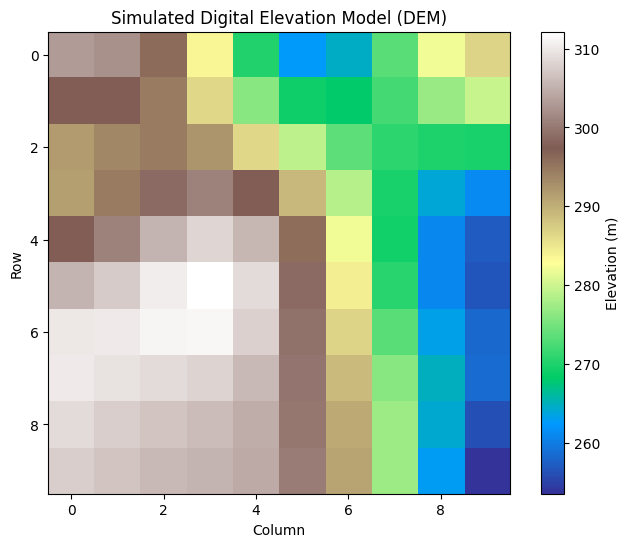

In [20]:
import matplotlib.pyplot as plt

# สร้างข้อมูล DEM จำลอง (10x10 grid)
np.random.seed(42)
dem = np.random.uniform(100, 500, size=(10, 10))

# ทำให้ข้อมูลเรียบขึ้น (จำลองภูเขา)
from scipy.ndimage import gaussian_filter
dem = gaussian_filter(dem, sigma=2)

print(f"DEM shape: {dem.shape}")
print(f"Min elevation: {dem.min():.1f} m")
print(f"Max elevation: {dem.max():.1f} m")
print(f"Mean elevation: {dem.mean():.1f} m")

# แสดงผลเป็นแผนที่
plt.figure(figsize=(8, 6))
plt.imshow(dem, cmap='terrain')
plt.colorbar(label='Elevation (m)')
plt.title('Simulated Digital Elevation Model (DEM)')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

## 6.2 คำนวณ Slope (ความชัน) จาก DEM

Slope min: 1.81 deg
Slope max: 25.39 deg
Slope mean: 13.00 deg


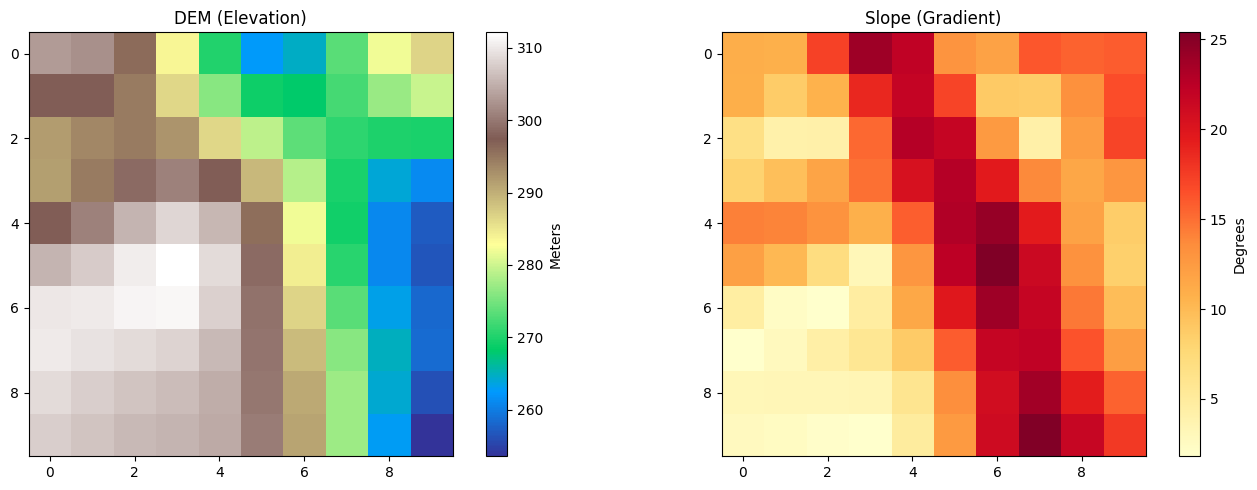

In [21]:
# คำนวณ Slope จาก DEM โดยใช้ NumPy gradient
cell_size = 30  # ขนาด pixel (เมตร)

# คำนวณ gradient ในแนว x และ y
dy, dx = np.gradient(dem, cell_size)
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

print(f"Slope min: {slope_deg.min():.2f} deg")
print(f"Slope max: {slope_deg.max():.2f} deg")
print(f"Slope mean: {slope_deg.mean():.2f} deg")

# แสดงผล
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(dem, cmap='terrain')
axes[0].set_title('DEM (Elevation)')
plt.colorbar(im1, ax=axes[0], label='Meters')

im2 = axes[1].imshow(slope_deg, cmap='YlOrRd')
axes[1].set_title('Slope (Gradient)')
plt.colorbar(im2, ax=axes[1], label='Degrees')

plt.tight_layout()
plt.show()

## 6.3 คำนวณ NDVI จากข้อมูลดาวเทียม

NDVI range: -0.377 to 0.863
NDVI mean: 0.384

Land Classification (100 pixels):
  Water (NDVI < 0): 12 px (12.0%)
  Bare soil (0-0.2): 15 px (15.0%)
  Moderate vegetation (0.2-0.5): 32 px (32.0%)
  Dense vegetation (>0.5): 41 px (41.0%)


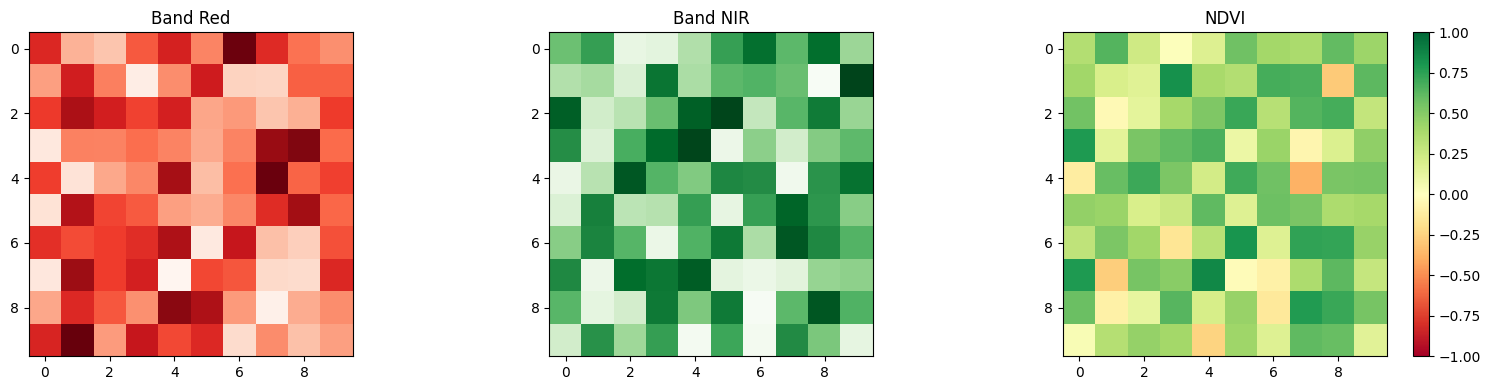

In [22]:
# จำลองข้อมูลดาวเทียม Band Red และ NIR (10x10 pixel)
np.random.seed(123)
band_red = np.random.uniform(0.05, 0.3, size=(10, 10))
band_nir = np.random.uniform(0.1, 0.8, size=(10, 10))

# คำนวณ NDVI
ndvi = (band_nir - band_red) / (band_nir + band_red)

print(f"NDVI range: {ndvi.min():.3f} to {ndvi.max():.3f}")
print(f"NDVI mean: {ndvi.mean():.3f}")

# จำแนกพื้นที่จาก NDVI
water = np.sum(ndvi < 0)           # น้ำ
bare = np.sum((ndvi >= 0) & (ndvi < 0.2))    # ดินเปล่า
vegetation = np.sum((ndvi >= 0.2) & (ndvi < 0.5))  # พืชพรรณปานกลาง
dense_veg = np.sum(ndvi >= 0.5)    # พืชพรรณหนาแน่น

total = ndvi.size
print(f"\nLand Classification ({total} pixels):")
print(f"  Water (NDVI < 0): {water} px ({water/total*100:.1f}%)")
print(f"  Bare soil (0-0.2): {bare} px ({bare/total*100:.1f}%)")
print(f"  Moderate vegetation (0.2-0.5): {vegetation} px ({vegetation/total*100:.1f}%)")
print(f"  Dense vegetation (>0.5): {dense_veg} px ({dense_veg/total*100:.1f}%)")

# แสดงผล
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(band_red, cmap='Reds')
axes[0].set_title('Band Red')

axes[1].imshow(band_nir, cmap='Greens')
axes[1].set_title('Band NIR')

im = axes[2].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
axes[2].set_title('NDVI')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()

## 6.4 วิเคราะห์ข้อมูล PM2.5 หลายจังหวัด (2D Array)

In [23]:
# PM2.5 (μg/m³) ของ 5 จังหวัด x 7 วัน
pm25_data = np.array([
    [45, 52, 78, 120, 95, 60, 42],    # กรุงเทพฯ
    [80, 95, 150, 180, 130, 85, 70],   # เชียงใหม่
    [30, 35, 28, 40, 45, 32, 25],      # ภูเก็ต
    [55, 65, 88, 110, 75, 50, 48],     # ขอนแก่น
    [25, 30, 22, 35, 28, 20, 18]       # สงขลา
])
provinces = ["กรุงเทพฯ", "เชียงใหม่", "ภูเก็ต", "ขอนแก่น", "สงขลา"]
days = ["จ.", "อ.", "พ.", "พฤ.", "ศ.", "ส.", "อา."]

# สถิติรายจังหวัด
print("=== สรุป PM2.5 รายจังหวัด ===")
print(f"{'จังหวัด':<12} {'เฉลี่ย':>8} {'สูงสุด':>8} {'ต่ำสุด':>8}")
print("-" * 40)
for i, prov in enumerate(provinces):
    avg = np.mean(pm25_data[i])
    mx = np.max(pm25_data[i])
    mn = np.min(pm25_data[i])
    print(f"{prov:<12} {avg:>8.1f} {mx:>8.0f} {mn:>8.0f}")

print(f"\nจังหวัดที่ PM2.5 เฉลี่ยสูงสุด: {provinces[np.argmax(np.mean(pm25_data, axis=1))]}")
print(f"จังหวัดที่ PM2.5 เฉลี่ยต่ำสุด: {provinces[np.argmin(np.mean(pm25_data, axis=1))]}")

# นับวันที่เกินมาตรฐาน (50 μg/m³)
exceed = np.sum(pm25_data > 50, axis=1)
print(f"\nจำนวนวันที่ PM2.5 เกิน 50 μg/m³:")
for prov, count in zip(provinces, exceed):
    print(f"  {prov}: {count} วัน")

=== สรุป PM2.5 รายจังหวัด ===
จังหวัด        เฉลี่ย   สูงสุด   ต่ำสุด
----------------------------------------
กรุงเทพฯ         70.3      120       42
เชียงใหม่       112.9      180       70
ภูเก็ต           33.6       45       25
ขอนแก่น          70.1      110       48
สงขลา            25.4       35       18

จังหวัดที่ PM2.5 เฉลี่ยสูงสุด: เชียงใหม่
จังหวัดที่ PM2.5 เฉลี่ยต่ำสุด: สงขลา

จำนวนวันที่ PM2.5 เกิน 50 μg/m³:
  กรุงเทพฯ: 5 วัน
  เชียงใหม่: 7 วัน
  ภูเก็ต: 0 วัน
  ขอนแก่น: 5 วัน
  สงขลา: 0 วัน


---
# ส่วนที่ 7: แบบฝึกหัด

ทำแบบฝึกหัดต่อไปนี้ให้ครบ แล้วรันโค้ดเพื่อตรวจสอบผลลัพธ์

### แบบฝึกหัดที่ 1: สร้างและจัดการ Array
1. สร้าง 1D array ของระดับความสูง (เมตร) 10 ค่า ตั้งแต่ 100 ถึง 1000
2. หาค่าเฉลี่ย, สูงสุด, ต่ำสุด ของระดับความสูง
3. หาว่ามีกี่จุดที่สูงกว่า 500 เมตร

In [24]:
# 1. สร้าง 1D array ของระดับความสูง (เมตร) 10 ค่า ตั้งแต่ 100 ถึง 1000
elevations_ex1 = np.linspace(100, 1000, 10)
print("1D Array ระดับความสูง:", elevations_ex1)

# 2. หาค่าเฉลี่ย, สูงสุด, ต่ำสุด ของระดับความสูง
mean_elevation = np.mean(elevations_ex1)
max_elevation = np.max(elevations_ex1)
min_elevation = np.min(elevations_ex1)

print(f"ค่าเฉลี่ยระดับความสูง: {mean_elevation:.1f} เมตร")
print(f"ระดับความสูงสูงสุด: {max_elevation:.1f} เมตร")
print(f"ระดับความสูงต่ำสุด: {min_elevation:.1f} เมตร")

# 3. หาว่ามีกี่จุดที่สูงกว่า 500 เมตร
points_above_500 = np.sum(elevations_ex1 > 500)
print(f"จำนวนจุดที่สูงกว่า 500 เมตร: {points_above_500} จุด")

1D Array ระดับความสูง: [ 100.  200.  300.  400.  500.  600.  700.  800.  900. 1000.]
ค่าเฉลี่ยระดับความสูง: 550.0 เมตร
ระดับความสูงสูงสุด: 1000.0 เมตร
ระดับความสูงต่ำสุด: 100.0 เมตร
จำนวนจุดที่สูงกว่า 500 เมตร: 5 จุด


### แบบฝึกหัดที่ 2: ข้อมูล 2 มิติ
สร้างตารางปริมาณฝน (มม.) ขนาด 4 จังหวัด x 12 เดือน โดยใช้ข้อมูลสุ่ม (0-300 มม.)
1. หาเดือนที่ฝนตกมากที่สุดของแต่ละจังหวัด
2. หาปริมาณฝนรวมทั้งปีของแต่ละจังหวัด
3. หาจังหวัดที่ฝนตกน้อยที่สุดตลอดปี

In [25]:
# 1. สร้างตารางปริมาณฝน (มม.) ขนาด 4 จังหวัด x 12 เดือน โดยใช้ข้อมูลสุ่ม (0-300 มม.)
np.random.seed(42) # เพื่อให้ผลลัพธ์สุ่มซ้ำได้
rainfall_data = np.random.uniform(0, 300, size=(4, 12))

provinces_ex2 = ["จันทบุรี", "ระยอง", "ตราด", "ชลบุรี"]
months_ex2 = ["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.",
              "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."]

print("ตารางปริมาณฝน (มม.):")
print(np.round(rainfall_data, 1))
print()

# 2. หาเดือนที่ฝนตกมากที่สุดของแต่ละจังหวัด
print("=== เดือนที่ฝนตกมากที่สุดของแต่ละจังหวัด ===")
for i, prov in enumerate(provinces_ex2):
    max_month_index = np.argmax(rainfall_data[i])
    print(f"  {prov}: {months_ex2[max_month_index]} ({rainfall_data[i, max_month_index]:.1f} มม.)")
print()

# 3. หาปริมาณฝนรวมทั้งปีของแต่ละจังหวัด
print("=== ปริมาณฝนรวมทั้งปีของแต่ละจังหวัด ===")
total_rainfall_by_province = np.sum(rainfall_data, axis=1)
for i, prov in enumerate(provinces_ex2):
    print(f"  {prov}: {total_rainfall_by_province[i]:.1f} มม.")
print()

# 4. หาจังหวัดที่ฝนตกน้อยที่สุดตลอดปี
min_rainfall_province_index = np.argmin(total_rainfall_by_province)
print(f"จังหวัดที่ฝนตกน้อยที่สุดตลอดปี: {provinces_ex2[min_rainfall_province_index]} ({total_rainfall_by_province[min_rainfall_province_index]:.1f} มม.)")

ตารางปริมาณฝน (มม.):
[[112.4 285.2 219.6 179.6  46.8  46.8  17.4 259.9 180.3 212.4   6.2 291. ]
 [249.7  63.7  54.5  55.   91.3 157.4 129.6  87.4 183.6  41.8  87.6 109.9]
 [136.8 235.6  59.9 154.3 177.7  13.9 182.3  51.2  19.5 284.7 289.7 242.5]
 [ 91.4  29.3 205.3 132.   36.6 148.6  10.3 272.8  77.6 198.8  93.5 156. ]]

=== เดือนที่ฝนตกมากที่สุดของแต่ละจังหวัด ===
  จันทบุรี: ธ.ค. (291.0 มม.)
  ระยอง: ม.ค. (249.7 มม.)
  ตราด: พ.ย. (289.7 มม.)
  ชลบุรี: ส.ค. (272.8 มม.)

=== ปริมาณฝนรวมทั้งปีของแต่ละจังหวัด ===
  จันทบุรี: 1857.6 มม.
  ระยอง: 1311.6 มม.
  ตราด: 1848.0 มม.
  ชลบุรี: 1452.2 มม.

จังหวัดที่ฝนตกน้อยที่สุดตลอดปี: ระยอง (1311.6 มม.)


### แบบฝึกหัดที่ 3: NDVI Analysis
กำหนดข้อมูลดาวเทียม:
- band_red = [0.12, 0.08, 0.25, 0.15, 0.30, 0.05, 0.18, 0.22]
- band_nir = [0.45, 0.60, 0.20, 0.55, 0.15, 0.70, 0.40, 0.30]

1. คำนวณ NDVI ทุกจุด
2. จำแนกแต่ละจุดว่าเป็น น้ำ/ดินเปล่า/พืชพรรณ
3. หาจุดที่มีความเขียวมากที่สุด

In [26]:
import numpy as np

# กำหนดข้อมูลดาวเทียม:
band_red = np.array([0.12, 0.08, 0.25, 0.15, 0.30, 0.05, 0.18, 0.22])
band_nir = np.array([0.45, 0.60, 0.20, 0.55, 0.15, 0.70, 0.40, 0.30])

# 1. คำนวณ NDVI ทุกจุด
ndvi = (band_nir - band_red) / (band_nir + band_red)
print("NDVI values:", np.round(ndvi, 3))
print(f"NDVI range: {ndvi.min():.3f} to {ndvi.max():.3f}")

# 2. จำแนกแต่ละจุดว่าเป็น น้ำ/ดินเปล่า/พืชพรรณ
classification = []
for val in ndvi:
    if val < 0:
        classification.append("น้ำ")
    elif 0 <= val < 0.2:
        classification.append("ดินเปล่า")
    elif 0.2 <= val < 0.5:
        classification.append("พืชพรรณปานกลาง")
    else:
        classification.append("พืชพรรณหนาแน่น")

print("\nClassification:", classification)

# 3. หาจุดที่มีความเขียวมากที่สุด
max_ndvi_index = np.argmax(ndvi)
print(f"จุดที่มีความเขียวมากที่สุดคือจุดที่ {max_ndvi_index} ด้วยค่า NDVI: {ndvi[max_ndvi_index]:.3f}")

NDVI values: [ 0.579  0.765 -0.111  0.571 -0.333  0.867  0.379  0.154]
NDVI range: -0.333 to 0.867

Classification: ['พืชพรรณหนาแน่น', 'พืชพรรณหนาแน่น', 'น้ำ', 'พืชพรรณหนาแน่น', 'น้ำ', 'พืชพรรณหนาแน่น', 'พืชพรรณปานกลาง', 'ดินเปล่า']
จุดที่มีความเขียวมากที่สุดคือจุดที่ 5 ด้วยค่า NDVI: 0.867


### แบบฝึกหัดที่ 4: Reshape & สถิติ
1. สร้าง 1D array ตัวเลข 1-24
2. Reshape เป็น (4, 6) → สมมติเป็น 4 สถานี x 6 เดือน
3. หาค่าเฉลี่ยของแต่ละสถานี (axis=1)
4. Transpose แล้วหาค่าเฉลี่ยของแต่ละเดือน

In [27]:
# 1. สร้าง 1D array ตัวเลข 1-24
data_ex4 = np.arange(1, 25)
print("1D Array (1-24):", data_ex4)
print(f"Shape: {data_ex4.shape}")

# 2. Reshape เป็น (4, 6) → สมมติเป็น 4 สถานี x 6 เดือน
stations_data = data_ex4.reshape(4, 6)
print("\nReshaped to (4 สถานี x 6 เดือน):")
print(stations_data)
print(f"Shape: {stations_data.shape}")

# 3. หาค่าเฉลี่ยของแต่ละสถานี (axis=1)
mean_by_station = np.mean(stations_data, axis=1)
print("\nค่าเฉลี่ยของแต่ละสถานี:", np.round(mean_by_station, 2))

# 4. Transpose แล้วหาค่าเฉลี่ยของแต่ละเดือน
transposed_data = stations_data.T
print("\nTranspose data (6 เดือน x 4 สถานี):")
print(transposed_data)
print(f"Shape: {transposed_data.shape}")

mean_by_month = np.mean(transposed_data, axis=1)
print("\nค่าเฉลี่ยของแต่ละเดือน:", np.round(mean_by_month, 2))

1D Array (1-24): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Shape: (24,)

Reshaped to (4 สถานี x 6 เดือน):
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]]
Shape: (4, 6)

ค่าเฉลี่ยของแต่ละสถานี: [ 3.5  9.5 15.5 21.5]

Transpose data (6 เดือน x 4 สถานี):
[[ 1  7 13 19]
 [ 2  8 14 20]
 [ 3  9 15 21]
 [ 4 10 16 22]
 [ 5 11 17 23]
 [ 6 12 18 24]]
Shape: (6, 4)

ค่าเฉลี่ยของแต่ละเดือน: [10. 11. 12. 13. 14. 15.]


---
### สรุปฟังก์ชัน NumPy ที่สำคัญ

| ฟังก์ชัน | ความหมาย | ตัวอย่าง |
|----------|----------|----------|
| `np.array()` | สร้าง array | `np.array([1,2,3])` |
| `np.zeros()` | array ศูนย์ | `np.zeros((3,4))` |
| `np.ones()` | array หนึ่ง | `np.ones((2,5))` |
| `np.arange()` | ลำดับตัวเลข | `np.arange(0,10,2)` |
| `np.linspace()` | เว้นเท่ากัน | `np.linspace(0,1,5)` |
| `.shape` | ดูรูปร่าง | `arr.shape` |
| `.reshape()` | เปลี่ยนรูปร่าง | `arr.reshape(3,4)` |
| `.T` | transpose | `arr.T` |
| `np.sum()` | ผลรวม | `np.sum(arr, axis=0)` |
| `np.mean()` | ค่าเฉลี่ย | `np.mean(arr, axis=1)` |
| `np.max()` / `np.min()` | ค่าสูงสุด/ต่ำสุด | `np.max(arr)` |
| `np.argmax()` | ตำแหน่งค่าสูงสุด | `np.argmax(arr)` |
| `np.std()` | ส่วนเบี่ยงเบน | `np.std(arr)` |
| `np.gradient()` | ค่า gradient | `np.gradient(dem)` |

---
**สัปดาห์หน้า:** การพัฒนาแผนที่ด้วย Leafmap